<a href="https://colab.research.google.com/github/RashiBista/practice1/blob/main/word_embeddings_word2vec_glove_fasttext.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Word Embeddings, Interactively: Word2Vec · GloVe · FastText



This notebook builds intuition for how words become **vectors**, and how three
landmark methods do it:

| Method | Core idea | Year |
|---|---|---|
| **Word2Vec** (CBOW & Skip-gram) | Predict words from local context windows | 2013 |
| **GloVe** | Factorize a global word co-occurrence matrix | 2014 |
| **FastText** | Word2Vec **+ subword n-grams** (handles unseen words) | 2016 |

What you will do here:

1. See *why* dense vectors beat one-hot encodings.
2. **Build CBOW and Skip-gram from scratch in NumPy** and train them, watching the loss fall.
3. Train a *real* Word2Vec model with `gensim` and explore neighbours.
4. Reproduce the famous analogy **`king − man + woman ≈ queen`** — both geometrically (offline) and with real pretrained vectors.
5. Build a **co-occurrence matrix** to understand GloVe.
6. Watch **FastText reconstruct a vector for a word it has never seen**, and see why this matters for morphologically rich languages like Nepali.
7. Compare all three side by side.

> **How to run:** execute cells top to bottom (`Shift+Enter`). The from-scratch
> and `gensim` sections run fully offline. Only the *pretrained-vector* analogy
> cell downloads ~66 MB and needs internet (works on Google Colab out of the box).


## 0. Setup

If a package is missing, uncomment the install line. On Google Colab, `gensim`,
`numpy`, `matplotlib`, and `scikit-learn` are already available.


In [1]:
!pip install numpy matplotlib scikit-learn gensim ipywidgets

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# ipywidgets is optional — used for the interactive sliders/dropdowns.
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
    print("ipywidgets available — interactive controls enabled.")
except Exception:
    HAS_WIDGETS = False
    print("ipywidgets not found — interactive cells will fall back to static output.")

print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 58.5 MB/s eta 0:00:00
ipywidgets available — interactive controls enabled.
Setup complete.


## 1. Why embeddings? One-hot vs. dense vectors

A computer cannot read the word *king*. We must turn it into numbers.

**One-hot encoding** gives each word its own slot in a giant vector that is all
zeros except for a single 1:

```
king  = [0, 0, 1, 0, 0, ... , 0]   # length = vocabulary size (could be 100,000+)
queen = [0, 0, 0, 1, 0, ... , 0]
```

Two problems:

- **Huge and wasteful** — a 50,000-word vocabulary means 50,000-dim vectors.
- **No meaning** — every pair of distinct words is equally dissimilar. The
  similarity between *king* and *queen* is exactly 0, the same as *king* and *banana*.

An **embedding** instead places each word at a point in a *dense, low-dimensional*
space (say 50–300 dims) that is **learned** so that words used in similar contexts
sit close together. The geometry then carries meaning.

> **The distributional hypothesis** (Firth, 1957): *"You shall know a word by the
> company it keeps."* Words appearing in similar contexts tend to have similar meanings.
> Every method in this notebook is a different way of cashing in on this single idea.


In [2]:
# A toy illustration: one-hot has zero similarity between any two different words,
# while a learned embedding can encode that 'king' and 'queen' are related.

words = ["king", "queen", "banana"]
onehot = np.eye(3)

def cosine(a, b):
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

print("ONE-HOT cosine similarities (everything is 0 — no meaning):")
print(f"  king~queen  = {cosine(onehot[0], onehot[1]):.2f}")
print(f"  king~banana = {cosine(onehot[0], onehot[2]):.2f}")

# Hand-set 'embeddings' just to show the contrast (real ones are learned later)
emb = {
    "king":   np.array([0.9, 0.8]),
    "queen":  np.array([0.85, 0.9]),
    "banana": np.array([-0.7, 0.2]),
}
print("\nDENSE EMBEDDING cosine similarities (meaning emerges):")
print(f"  king~queen  = {cosine(emb['king'], emb['queen']):.2f}")
print(f"  king~banana = {cosine(emb['king'], emb['banana']):.2f}")

ONE-HOT cosine similarities (everything is 0 — no meaning):
  king~queen  = 0.00
  king~banana = 0.00

DENSE EMBEDDING cosine similarities (meaning emerges):
  king~queen  = 1.00
  king~banana = -0.54


## 2. Word2Vec: two ways to learn from context

Word2Vec slides a **context window** across the text. For a chosen window size
`w`, the *context* of a center word is the `w` words on each side.

> Sentence: `the   quick   [brown]   fox   jumps`   with window = 2
> center = **brown**, context = {the, quick, fox, jumps}

There are **two training objectives**, which are mirror images of each other:

- **CBOW (Continuous Bag-of-Words):** use the *context* to **predict the center word**.
  `{the, quick, fox, jumps} → brown`. Faster; smooths over data; good for frequent words.

- **Skip-gram:** use the *center word* to **predict each context word**.
  `brown → the`, `brown → quick`, `brown → fox`, `brown → jumps`. Slower; works
  better on small corpora and rare words.

Both train a shallow network. The **input-side weight matrix** `W1` (shape
`vocab × dim`) *is* the embedding table — after training, row `i` is the vector for word `i`.


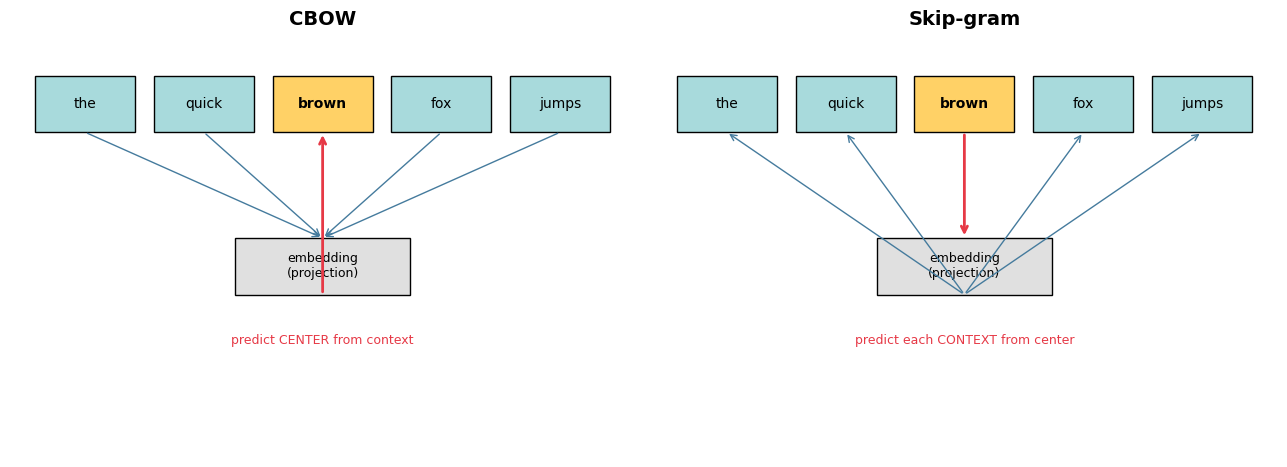

In [3]:
# Visualise the context window and the CBOW vs Skip-gram data flow.
def draw_architectures():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    sent = ["the", "quick", "brown", "fox", "jumps"]
    center_idx = 2

    for ax, mode in zip(axes, ["CBOW", "Skip-gram"]):
        ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis("off")
        ax.set_title(f"{mode}", fontsize=14, fontweight="bold")
        # draw the sentence
        for i, w in enumerate(sent):
            is_center = (i == center_idx)
            ax.add_patch(plt.Rectangle((0.4 + i*1.9, 4.6), 1.6, 0.8,
                         fc=("#ffd166" if is_center else "#a8dadc"), ec="black"))
            ax.text(1.2 + i*1.9, 5.0, w, ha="center", va="center", fontsize=10,
                    fontweight=("bold" if is_center else "normal"))
        # hidden / projection
        ax.add_patch(plt.Rectangle((3.6, 2.3), 2.8, 0.8, fc="#e0e0e0", ec="black"))
        ax.text(5.0, 2.7, "embedding\n(projection)", ha="center", va="center", fontsize=9)
        # arrows
        ctx = [0, 1, 3, 4]
        if mode == "CBOW":            # paila brown bhayek aru lai one hot encoding use garcha then it will relate them with brown
            for i in ctx:  # context -> hidden
                ax.annotate("", xy=(5.0, 3.1), xytext=(1.2 + i*1.9, 4.6),
                            arrowprops=dict(arrowstyle="->", color="#457b9d"))
            ax.annotate("", xy=(1.2 + center_idx*1.9, 4.6), xytext=(5.0, 2.3),
                        arrowprops=dict(arrowstyle="->", color="#e63946", lw=2))
            ax.text(5.0, 1.6, "predict CENTER from context", ha="center",
                    fontsize=9, color="#e63946")
        else:
            ax.annotate("", xy=(5.0, 3.1), xytext=(1.2 + center_idx*1.9, 4.6),
                        arrowprops=dict(arrowstyle="->", color="#e63946", lw=2))
            for i in ctx:  # hidden -> each context
                ax.annotate("", xy=(1.2 + i*1.9, 4.6), xytext=(5.0, 2.3),
                            arrowprops=dict(arrowstyle="->", color="#457b9d"))
            ax.text(5.0, 1.6, "predict each CONTEXT from center", ha="center",
                    fontsize=9, color="#e63946")
    plt.tight_layout(); plt.show()

draw_architectures()

### Interactive: explore the context window

Drag the **center position** and **window size** to see exactly which
(center, context) training pairs Word2Vec extracts from a sentence.


In [4]:
sentence = "the quick brown fox jumps over the lazy dog".split()

def show_window(center=3, window=2):
    n = len(sentence)
    lo, hi = max(0, center - window), min(n - 1, center + window)
    ctx = [sentence[j] for j in range(lo, hi + 1) if j != center]
    parts = []
    for i, w in enumerate(sentence):
        if i == center:
            parts.append(f"[{w.upper()}]")
        elif lo <= i <= hi:
            parts.append(f"<{w}>")
        else:
            parts.append(w)
    print(" ".join(parts))
    print(f"\nCenter word : {sentence[center]}")
    print(f"Context     : {ctx}")
    print(f"\nCBOW pair      : ({ctx}) -> {sentence[center]}")
    print("Skip-gram pairs:", [f"{sentence[center]} -> {c}" for c in ctx])

if HAS_WIDGETS:
    widgets.interact(show_window,
                     center=widgets.IntSlider(min=0, max=len(sentence)-1, value=3, description="center"),
                     window=widgets.IntSlider(min=1, max=4, value=2, description="window"))
else:
    show_window(3, 2)

interactive(children=(IntSlider(value=3, description='center', max=8), IntSlider(value=2, description='window'…

## 3. CBOW from scratch (NumPy)

Let's implement CBOW with nothing but NumPy so the mechanics are fully visible.

**The forward pass:**

1. Look up the embedding of each context word in `W1` and **average** them → hidden vector `h`.
2. Score every vocabulary word: `u = h · W2`.
3. **Softmax** → probability distribution over the vocabulary.

**The loss:** cross-entropy between the prediction and the true center word.

**The backward pass:** gradient descent nudges `W1` and `W2` so the true center
word gets higher probability next time. We derive the gradients by hand below.

We use a tiny royal/gender corpus so patterns emerge in a few hundred epochs.


In [5]:
# ---- Tiny corpus (designed so gender/royalty structure is learnable) ----
raw = ("the king is a strong man . the queen is a wise woman . "
       "the king rules the kingdom . the queen rules the kingdom . "
       "a man is strong . a woman is wise . "
       "the prince is a young man . the princess is a young woman . "
       "the king loves the queen . the man loves the woman . "
       "the prince loves the princess . the boy is a young man . "
       "the girl is a young woman . the boy loves the girl .")
tokens = raw.split()

vocab = sorted(set(tokens))
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}
V = len(vocab)
print(f"Vocabulary size V = {V}")
print(vocab)

def make_pairs(toks, window):
    pairs = []
    for i, t in enumerate(toks):
        ctx = [toks[j] for j in range(max(0, i-window), min(len(toks), i+window+1)) if j != i]
        if ctx:
            pairs.append((t, ctx))
    return pairs

WINDOW = 2
pairs = make_pairs(tokens, WINDOW)
print(f"\nTotal (center, context) pairs: {len(pairs)}")
print("Example:", pairs[1])

Vocabulary size V = 18
['.', 'a', 'boy', 'girl', 'is', 'king', 'kingdom', 'loves', 'man', 'prince', 'princess', 'queen', 'rules', 'strong', 'the', 'wise', 'woman', 'young']

Total (center, context) pairs: 88
Example: ('king', ['the', 'is', 'a'])


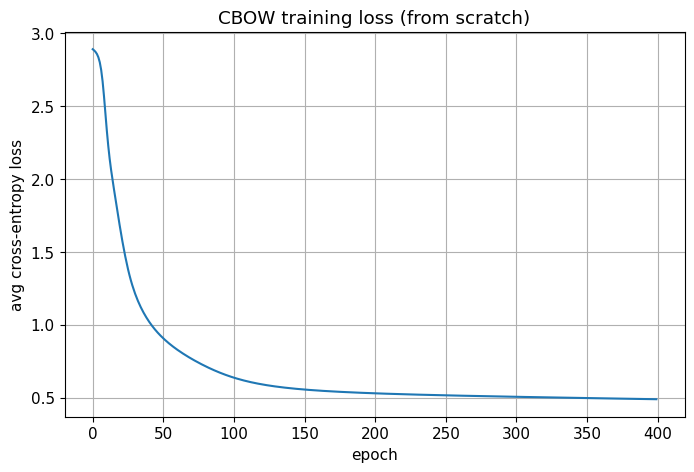

Final loss: 0.491


In [6]:
def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def train_cbow(pairs, V, dim=12, lr=0.05, epochs=400, seed=1):
    rng = np.random.default_rng(seed)
    W1 = rng.standard_normal((V, dim)) * 0.1   # INPUT embeddings  (this is the table we keep)
    W2 = rng.standard_normal((dim, V)) * 0.1   # OUTPUT weights
    history = []
    for epoch in range(epochs):
        loss = 0.0
        for center, ctx in pairs:
            ci = [w2i[c] for c in ctx]
            ti = w2i[center]
            h = W1[ci].mean(axis=0)            # average context embeddings -> (dim,)
            u = h @ W2                          # scores -> (V,)
            y = softmax(u)                      # probabilities -> (V,)
            loss += -np.log(y[ti] + 1e-9)       # cross-entropy
            # ---- gradients ----
            e = y.copy(); e[ti] -= 1            # dL/du  -> (V,)
            dW2 = np.outer(h, e)                # (dim, V)
            dh  = W2 @ e                         # (dim,)
            # ---- update ----
            W2 -= lr * dW2
            for c in ci:                         # gradient flows equally to each context word
                W1[c] -= lr * dh / len(ci)
        history.append(loss / len(pairs))
    return W1, W2, history

EMB_DIM = 12
W1_cbow, W2_cbow, hist_cbow = train_cbow(pairs, V, dim=EMB_DIM, epochs=400)

plt.plot(hist_cbow)
plt.xlabel("epoch"); plt.ylabel("avg cross-entropy loss")
plt.title("CBOW training loss (from scratch)")
plt.show()
print(f"Final loss: {hist_cbow[-1]:.3f}")

In [7]:
# The embedding table is W1. Let's find nearest neighbours by cosine similarity.
def neighbours(word, table, k=5):
    if word not in w2i:
        return f"'{word}' not in vocabulary"
    v = table[w2i[word]]
    sims = []
    for w, i in w2i.items():
        if w == word:
            continue
        sims.append((w, cosine(v, table[i])))
    return sorted(sims, key=lambda x: -x[1])[:k]

for q in ["king", "queen", "man", "woman"]:
    print(f"{q:8s} -> {neighbours(q, W1_cbow)}")

king     -> [('rules', 0.597160124681158), ('prince', 0.5673051271752116), ('boy', 0.3830420937800173), ('man', 0.30945600857875205), ('.', 0.2732967755100039)]
queen    -> [('princess', 0.897672466347543), ('girl', 0.8722651370636119), ('boy', 0.7212871995314674), ('young', 0.7092912274066027), ('prince', 0.5723096905506818)]
man      -> [('boy', 0.7055435229875504), ('prince', 0.6522306943275137), ('woman', 0.5432581436565753), ('girl', 0.4866576352212606), ('princess', 0.4399146783526894)]
woman    -> [('boy', 0.5729401200882587), ('man', 0.5432581436565753), ('princess', 0.5295190710664803), ('girl', 0.525463808931968), ('queen', 0.4736591671736431)]


## 4. Skip-gram from scratch (NumPy)

Now the mirror image. The center word predicts **each** context word, so a single
center generates several (center → context) training examples. Skip-gram tends to
learn better representations for **rare words** because every context word gives
the center its own, sharper update.


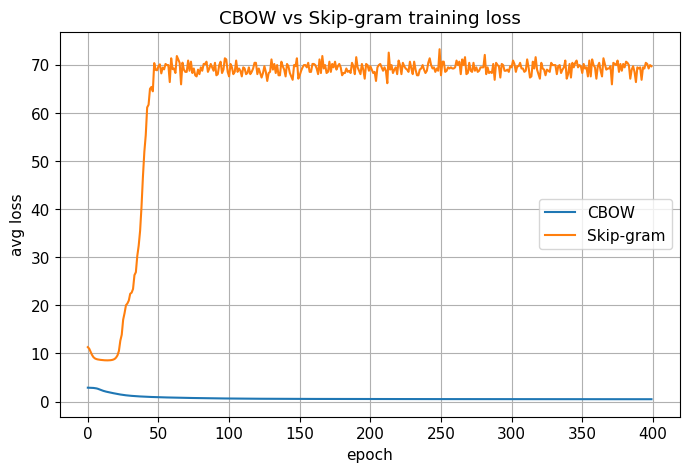

king     -> [('princess', 0.992787376307246), ('boy', 0.9658415693142176), ('queen', 0.9623124659408518), ('prince', 0.9016468431281904), ('kingdom', 0.8596122871568305)]
queen    -> [('princess', 0.962501974699986), ('king', 0.9623124659408518), ('prince', 0.9447637479649127), ('boy', 0.9335314413659895), ('girl', 0.8295735634935455)]
man      -> [('kingdom', 0.8956078514450608), ('woman', 0.803591647470727), ('boy', 0.7389000280123623), ('wise', 0.7338240548434058), ('young', 0.7150812123576529)]
woman    -> [('kingdom', 0.8114298878346433), ('man', 0.803591647470727), ('boy', 0.8017522567579594), ('princess', 0.7734718247029948), ('queen', 0.7485786020376031)]


In [8]:
def train_skipgram(pairs, V, dim=12, lr=0.05, epochs=400, seed=1):
    rng = np.random.default_rng(seed)
    W1 = rng.standard_normal((V, dim)) * 0.1   # INPUT embeddings (kept)
    W2 = rng.standard_normal((dim, V)) * 0.1   # OUTPUT weights
    history = []
    for epoch in range(epochs):
        loss = 0.0
        for center, ctx in pairs:
            ci = w2i[center]
            h = W1[ci]                          # center embedding -> (dim,)
            u = h @ W2                          # (V,)
            y = softmax(u)
            grad_h = np.zeros_like(h)
            for c in ctx:                        # one target at a time
                ti = w2i[c]
                loss += -np.log(y[ti] + 1e-9)
                e = y.copy(); e[ti] -= 1
                W2 -= lr * np.outer(h, e)        # update output weights
                grad_h += W2 @ e                 # accumulate gradient to the center
            W1[ci] -= lr * grad_h
        history.append(loss / len(pairs))
    return W1, W2, history

W1_sg, W2_sg, hist_sg = train_skipgram(pairs, V, dim=EMB_DIM, epochs=400)

plt.plot(hist_cbow, label="CBOW")
plt.plot(hist_sg, label="Skip-gram")
plt.xlabel("epoch"); plt.ylabel("avg loss"); plt.legend()
plt.title("CBOW vs Skip-gram training loss")
plt.show()

for q in ["king", "queen", "man", "woman"]:
    print(f"{q:8s} -> {neighbours(q, W1_sg)}")

### Visualising the learned space (2-D projection)

Our embeddings live in 12-D. We use **PCA** to flatten them to 2-D so we can plot
them. Watch how gendered / royal words cluster and how parallel relationships
(man→woman, king→queen, prince→princess, boy→girl) line up.


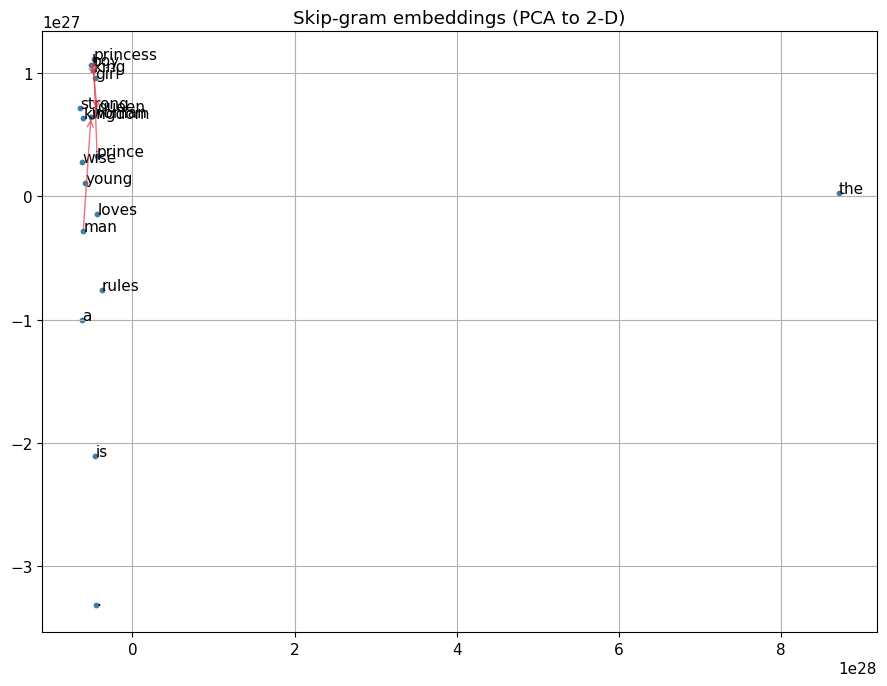

In [9]:
from sklearn.decomposition import PCA

def plot_embeddings(table, title):
    pts = PCA(n_components=2).fit_transform(table)
    plt.figure(figsize=(9, 7))
    plt.scatter(pts[:, 0], pts[:, 1], s=10, color="#457b9d")
    for w, i in w2i.items():
        plt.annotate(w, (pts[i, 0], pts[i, 1]), fontsize=11)
    # draw a few "gender" arrows if both words exist
    for a, b in [("man", "woman"), ("king", "queen"),
                 ("prince", "princess"), ("boy", "girl")]:
        if a in w2i and b in w2i:
            ia, ib = w2i[a], w2i[b]
            plt.annotate("", xy=(pts[ib, 0], pts[ib, 1]), xytext=(pts[ia, 0], pts[ia, 1]),
                         arrowprops=dict(arrowstyle="->", color="#e63946", alpha=0.7))
    plt.title(title); plt.tight_layout(); plt.show()

plot_embeddings(W1_sg, "Skip-gram embeddings (PCA to 2-D)")

## 5. A real Word2Vec model with `gensim`

Coding it by hand is great for understanding, but for real work you use an
optimised library. `gensim`'s `Word2Vec` adds the tricks that make it fast and
accurate: **negative sampling** (instead of a full softmax over the whole
vocabulary), **subsampling of frequent words**, and multithreading.

We train on a slightly larger themed corpus (repeated so there is enough signal).


In [ ]:
!
!pip install gensim
from gensim.models import Word2Vec

corpus_sentences = [s.split() for s in [
    "the king rules the kingdom with his royal army",
    "the queen rules the kingdom beside the king",
    "the prince is the young son of the king and the queen",
    "the princess is the young daughter of the king and the queen",
    "a man works hard in the field every single day",
    "a woman works hard in the field every single day",
    "the boy plays football in the school ground",
    "the girl plays football in the school ground",
    "paris is the capital city of france",
    "rome is the capital city of italy",
    "tokyo is the capital city of japan",
    "kathmandu is the capital city of nepal",
    "delhi is the capital city of india",
    "the man drives his car along the busy road",
    "the woman drives her car along the busy road",
]] * 60   # repeat to give the optimiser enough to learn from

# sg=1 -> Skip-gram ; sg=0 -> CBOW
model = Word2Vec(corpus_sentences, vector_size=60, window=3, min_count=1,
                 sg=1, negative=5, epochs=60, seed=1, workers=1)

print("Vocabulary size:", len(model.wv))
print("\nNeighbours of 'king' :", [w for w, _ in model.wv.most_similar("king", topn=4)])
print("Neighbours of 'nepal':", [w for w, _ in model.wv.most_similar("nepal", topn=4)])
print("\nSimilarity king~queen   :", round(model.wv.similarity("king", "queen"), 3))
print("Similarity king~football:", round(model.wv.similarity("king", "football"), 3))

## 6. The famous analogy: `king − man + woman ≈ queen`

This is the result that made word embeddings famous. If the embedding space has
learned that the *difference* between **king** and **man** is roughly "royalty
minus maleness", then adding **woman** should land you near **queen**:

$$ \vec{king} - \vec{man} + \vec{woman} \approx \vec{queen} $$

The same parallelogram holds for **country → capital**:
`paris − france + italy ≈ rome`.

### 6a. Geometric intuition (offline, always works)

First, a clean hand-made 2-D space so you can *see* the parallelogram. The vector
**man → king** is the same arrow as **woman → queen**.


In [ ]:
# Hand-built 2-D coordinates arranged so the analogy is an exact parallelogram.
coords = {
    "man":    np.array([1.0, 1.0]),  "woman":  np.array([1.0, 3.0]),
    "king":   np.array([5.0, 1.0]),  "queen":  np.array([5.0, 3.0]),
    "france": np.array([1.0, 6.0]),  "paris":  np.array([4.0, 6.0]),
    "italy":  np.array([1.0, 8.0]),  "rome":   np.array([4.0, 8.0]),
}

def analogy_2d(a, b, c):
    # a is to b as c is to ?   ->  result = b - a + c
    return coords[b] - coords[a] + coords[c]

result = analogy_2d("man", "king", "woman")   # king - man + woman
print("king - man + woman =", result, " (queen is at", coords["queen"], ")")

plt.figure(figsize=(8, 8))
for w, p in coords.items():
    plt.scatter(*p, s=60, color="#457b9d")
    plt.annotate(w, p, fontsize=12, xytext=(6, 6), textcoords="offset points")

def draw_arrow(a, b, color):
    plt.annotate("", xy=coords[b], xytext=coords[a],
                 arrowprops=dict(arrowstyle="->", color=color, lw=2))

draw_arrow("man", "king", "#e63946")     # the "royalty" direction
draw_arrow("woman", "queen", "#e63946")
draw_arrow("france", "paris", "#2a9d8f") # the "capital-of" direction
draw_arrow("italy", "rome", "#2a9d8f")
plt.scatter(*result, marker="*", s=400, color="gold", edgecolor="black",
            zorder=5, label="king - man + woman")
plt.legend(); plt.title("Vector arithmetic as parallelograms")
plt.xlim(0, 7); plt.ylim(0, 9); plt.tight_layout(); plt.show()

### 6b. The real thing: pretrained GloVe vectors

Toy corpora are too small to actually produce `queen` as the answer. To see the
*real* analogy we load **pretrained GloVe vectors** trained on billions of words.

> ⚠️ **This cell downloads ~66 MB** via `gensim.downloader` and needs internet.
> It runs out of the box on **Google Colab**. If you are offline, skip it — the
> geometry above already conveys the idea.


In [ ]:
try:
    import gensim.downloader as api
    print("Downloading pretrained GloVe vectors (glove-wiki-gigaword-100)... ~66 MB")
    glove = api.load("glove-wiki-gigaword-100")   # 400k words, 100-dim, trained on Wikipedia+Gigaword

    def analogy(positive, negative, topn=3):
        res = glove.most_similar(positive=positive, negative=negative, topn=topn)
        return res

    print("\nking - man + woman  =>", analogy(["king", "woman"], ["man"]))
    print("paris - france + italy =>", analogy(["paris", "italy"], ["france"]))
    print("better - good + bad =>", analogy(["better", "bad"], ["good"]))
    print("\nSanity check similarities:")
    print("  king ~ queen :", round(glove.similarity("king", "queen"), 3))
    print("  king ~ apple :", round(glove.similarity("king", "apple"), 3))
    GLOVE_OK = True
except Exception as ex:
    GLOVE_OK = False
    print("Could not load pretrained vectors (likely offline):", type(ex).__name__)
    print("That's fine — the geometric demo above already shows the concept.")

### 6c. Interactive analogy explorer

If the pretrained vectors loaded, type your own analogy: **A is to B as C is to ?**
The model computes `B − A + C` and returns the nearest words. Try
`man → king :: woman → ?` or `france → paris :: japan → ?`.


In [ ]:
def run_analogy(A="man", B="king", C="woman"):
    if not GLOVE_OK:
        print("Pretrained vectors not loaded; cannot run live analogies.")
        return
    A, B, C = A.lower().strip(), B.lower().strip(), C.lower().strip()
    for w in (A, B, C):
        if w not in glove:
            print(f"'{w}' is out of vocabulary. Try another word.")
            return
    res = glove.most_similar(positive=[B, C], negative=[A], topn=5)
    print(f"{A} is to {B}  as  {C} is to:")
    for word, score in res:
        print(f"    {word:15s} {score:.3f}")

if HAS_WIDGETS and GLOVE_OK:
    widgets.interact(run_analogy,
                     A=widgets.Text(value="man",   description="A:"),
                     B=widgets.Text(value="king",  description="B:"),
                     C=widgets.Text(value="woman", description="C:"))
else:
    run_analogy("man", "king", "woman")

## 7. GloVe: counting instead of predicting

Word2Vec is **predictive** — it slides a window and learns by predicting. **GloVe**
(Global Vectors) is **count-based**. Its insight: the *ratios* of global
co-occurrence counts already encode meaning. So GloVe:

1. Builds a giant **co-occurrence matrix** `X`, where `X[i, j]` = how often word `j`
   appears in the context of word `i` across the **entire corpus**.
2. Learns vectors so that the **dot product** of two word vectors approximates the
   **log of their co-occurrence count**:

$$ \vec{w_i} \cdot \vec{w_j} + b_i + b_j \approx \log X_{ij} $$

A weighting function down-weights very frequent pairs so "the the" doesn't dominate.

**Word2Vec vs GloVe in one line:** Word2Vec learns from *local windows, one at a
time*; GloVe fits *global statistics, all at once*. In practice they reach similar
quality — GloVe just bakes the corpus-wide counts in directly.

Below we build a small co-occurrence matrix by hand so you can see the raw material GloVe consumes.


In [ ]:
# Build a co-occurrence matrix from our CBOW corpus (window = 2).
def cooccurrence(toks, window=2):
    idx = {w: i for i, w in enumerate(sorted(set(toks)))}
    M = np.zeros((len(idx), len(idx)))
    for i, t in enumerate(toks):
        for j in range(max(0, i-window), min(len(toks), i+window+1)):
            if j != i:
                M[idx[t], idx[toks[j]]] += 1
    return M, idx

X, idx = cooccurrence(tokens, window=2)
labels = list(idx.keys())

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(np.log1p(X), cmap="viridis")
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.set_title("log(1 + co-occurrence count)  —  the raw material GloVe factorizes")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

# Inspect one row: who keeps company with 'king'?
king_row = X[idx["king"]]
companions = sorted(zip(labels, king_row), key=lambda x: -x[1])[:5]
print("Words that co-occur most with 'king':", companions)

## 8. FastText: words are made of pieces

Word2Vec and GloVe treat each word as an **atom** — *kingdom* and *kingdoms* are
unrelated unless both happen to appear often. Two consequences:

- A word **never seen in training** has **no vector at all** (out-of-vocabulary, OOV).
- Morphology is wasted: *play, plays, playing, played* are learned independently.

**FastText** fixes this. Each word is represented as a **bag of character n-grams**
plus the whole word. For `where` with n-grams of length 3:

```
<wh, whe, her, ere, re>   (plus the special whole-word token <where>)
```

A word's vector is the **sum of its subword vectors**. So:

- **Unseen words still get a vector** — built from their pieces.
- **Shared roots → shared subwords → similar vectors.** Great for morphologically
  rich languages.

This matters a lot for **Nepali**, which is highly inflected: घर (*ghar*, "house"),
घरमा (*gharma*, "in the house"), घरबाट (*gharbāṭa*, "from the house") all share the
root घर. FastText's subwords capture that the surface forms are related — Word2Vec
would treat each as an unrelated token.


In [ ]:
from gensim.models import FastText

ft = FastText(corpus_sentences, vector_size=60, window=3, min_count=1,
              sg=1, negative=5, epochs=60, seed=1, workers=1,
              min_n=2, max_n=4)   # character n-grams of length 2..4

print("FastText neighbours of 'king':", [w for w, _ in ft.wv.most_similar("king", topn=4)])

# ---- The key demonstration: a word that was NEVER in the training data ----
unseen = "kingdoms"          # plural form never appears in our corpus
print(f"\n'{unseen}' in Word2Vec vocab? ", unseen in model.wv)
print(f"'{unseen}' in FastText vocab? ", unseen in ft.wv.key_to_index)

print("\n--- Word2Vec on the unseen word ---")
try:
    _ = model.wv[unseen]
except KeyError:
    print(f"  KeyError: Word2Vec has NO vector for '{unseen}'. It is invisible.")

print("\n--- FastText on the unseen word ---")
vec = ft.wv[unseen]          # built from subwords <ki, kin, ing, ngd, ... >
print(f"  FastText produced a {vec.shape[0]}-dim vector from subwords.")
print(f"  Nearest known words: {[w for w, _ in ft.wv.most_similar(unseen, topn=4)]}")
print("  -> Notice 'kingdom' is near 'kingdoms' purely via shared character n-grams.")

### Subword similarity for morphology (romanized Nepali sketch)

A small illustration of why subwords help inflected languages. We train FastText on
a few romanized-Nepali-style sentences. Because *ghar*, *gharma*, *gharbata* share
the substring *ghar*, FastText places them near each other — and can even vectorise
an inflected form it never saw.


In [ ]:
nepali_like = [s.split() for s in [
    "ghar ramro cha malai ghar man parcha",
    "ma gharma baschu ani gharma khanaa khanchu",
    "u gharbata bahira gayo ani gharbata farkiyo",
    "pasal najik cha ma pasalma jaanchu",
    "u pasalbata saman kinera farkiyo",
    "school ramro cha kura schoolma padhcha",
]] * 80

ft_np = FastText(nepali_like, vector_size=40, window=3, min_count=1,
                 sg=1, epochs=80, seed=1, workers=1, min_n=2, max_n=4)

print("Words sharing the root 'ghar' (house):")
print("  ghar ~ gharma  :", round(ft_np.wv.similarity("ghar", "gharma"), 3))
print("  ghar ~ gharbata:", round(ft_np.wv.similarity("ghar", "gharbata"), 3))
print("  ghar ~ pasal   :", round(ft_np.wv.similarity("ghar", "pasal"), 3), " (unrelated root -> lower)")

unseen_np = "gharko"   # inflected form ("of the house") never in training
print(f"\nUnseen inflected form '{unseen_np}':")
print("  nearest known words:", [w for w, _ in ft_np.wv.most_similar(unseen_np, topn=3)])

## 9. Putting it together — how they differ

| | **Word2Vec** | **GloVe** | **FastText** |
|---|---|---|---|
| **Approach** | Predictive (local windows) | Count-based (global co-occurrence) | Predictive + **subword n-grams** |
| **Unit of meaning** | Whole word | Whole word | Word **+ character n-grams** |
| **Training signal** | Predict center/context word | Factorize co-occurrence matrix | Same as Word2Vec, on subwords |
| **Out-of-vocabulary words** | ❌ No vector (KeyError) | ❌ No vector | ✅ **Builds one from subwords** |
| **Morphology / rare words** | Weak | Weak | **Strong** |
| **Uses global corpus stats** | Indirectly | **Directly** | Indirectly |
| **Model size** | Small | Small | Larger (stores subword vectors) |
| **Good for** | General-purpose, large corpora | General-purpose, fast to train | Morphologically rich languages, typos, rare words, **Nepali / Devanagari** |
| **Authors / year** | Mikolov et al., Google, 2013 | Pennington et al., Stanford, 2014 | Bojanowski et al., Facebook, 2016 |

**One mental model:**

- *Word2Vec* — "I learn a word's meaning by repeatedly guessing it from its neighbours."
- *GloVe* — "I read the whole corpus once, count who appears with whom, and fit vectors to those counts."
- *FastText* — "Word2Vec, but I also look *inside* words at their letters, so I'm never stumped by a new word."

**A note on what came next.** All three give each word **one fixed vector** — *bank*
(river) and *bank* (money) share it. Modern **contextual** models (ELMo, BERT, and
today's large language models) give a word a *different* vector depending on the
sentence. But the core idea you built here — meaning as geometry in a learned vector
space — is the foundation they all stand on.
